In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from tqdm import tqdm
from IPython.display import display, Image
from PIL import Image
from einops import rearrange, repeat, reduce
from einops.layers.torch import Rearrange, Reduce
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torchsummary import summary

In [2]:
class PatchEmbedding(nn.Module):
    def __init__(self, inFeatures = 3, patchSize = 16, embedSize = 768, imageSize = 224):
        super(PatchEmbedding, self).__init__()
        self.pathchSize = patchSize
        self.projection = nn.Sequential(
            nn.Conv2d(in_channels = inFeatures, out_channels = embedSize, kernel_size = patchSize, stride = patchSize),
            Rearrange('b c (h) (w) -> b (h w) c')
        )
        self.clsToken = nn.Parameter(torch.randn(1, 1, embedSize))
        self.positions = nn.Parameter(torch.randn((imageSize // patchSize)**2 + 1, embedSize))

    def forward(self,x):
        b, _, _, _ = x.shape
        res = self.projection(x)
        clsTokens = repeat(self.clsToken, "() n e -> b n e", b = b)
        res = torch.cat([clsTokens, res], dim = 1)
        res += self.positions
        return res

In [3]:
class MultiHeadAttention(nn.Module):
    def __init__(self, embedSize = 768, numHeads = 8, dropout = 0):
        super(MultiHeadAttention,self).__init__()
        self.embedSize = embedSize
        self.numHeads = numHeads
        self.attentionDrop = nn.Dropout(p = dropout)
        self.qkv = nn.Linear(embedSize, embedSize * 3)
        self.projection = nn.Linear(embedSize, embedSize)


    def forward(self, x, mask = None):
        qkv = rearrange(self.qkv(x), "b n (h d qkv) -> (qkv) b h n d", h = self.numHeads, qkv = 3)
        q, k, v = qkv[0] , qkv[1], qkv[2]
        e = torch.einsum('bhqd, bhkd -> bhqk', q, k)
        if mask is not None:
            f = torch.finfo(torch.float32).min
            e.masked_fill(~mask, f)

        scale = self.embedSize ** (0.5)
        att = F.softmax(e, dim = -1)/scale
        att = self.attentionDrop(att)
        out = torch.einsum('bhal, bhlv -> bhav ', att, v)
        out = rearrange(out, "b h n d -> b n (h d)")
        out = self.projection(out)
        return out


In [4]:
class ResidualAdd(nn.Module):
    def __init__(self, fn):
        super().__init__()
        self.fn = fn

    def forward(self, x, **kwargs):
        res = x
        x = self.fn(x, **kwargs)
        x += res
        return x

In [5]:
class FeedForwardBlock(nn.Sequential):
    def __init__(self, emb_size: int, L: int = 4, drop_p: float = 0.):
        super().__init__(
            nn.Linear(emb_size, L * emb_size),
            nn.GELU(),
            nn.Dropout(drop_p),
            nn.Linear(L * emb_size, emb_size),
        )

In [6]:
class TransformerEncoderBlock(nn.Sequential):
    def __init__(self, emb_size: int = 768, drop_p: float = 0., forward_expansion: int = 4,
                 forward_drop_p: float = 0.,
                 **kwargs):

        super().__init__(
            ResidualAdd(nn.Sequential(
                nn.LayerNorm(emb_size),
                MultiHeadAttention(emb_size, **kwargs),
                nn.Dropout(drop_p)
            )),
            ResidualAdd(nn.Sequential(
                nn.LayerNorm(emb_size),
                FeedForwardBlock(
                    emb_size, L=forward_expansion, drop_p=forward_drop_p),
                nn.Dropout(drop_p)
            )
            ))

In [7]:
class TransformerEncoder(nn.Sequential):
    def __init__(self, depth: int = 12, **kwargs):
        super().__init__(*[TransformerEncoderBlock(**kwargs) for _ in range(depth)])

In [8]:
class ClassificationHead(nn.Sequential):
    def __init__(self, emb_size: int = 768, n_classes: int = 1000):
        super().__init__(
            Reduce('b n e -> b e', reduction='mean'),
            nn.LayerNorm(emb_size),
            nn.Linear(emb_size, n_classes))

In [9]:
class ViT(nn.Sequential):
    def __init__(self,
                in_channels: int = 3,
                patch_size: int = 32,
                emb_size: int = 128,
                img_size: int = 224,
                depth: int = 12,
                n_classes: int = 4,
                **kwargs):
        super().__init__(
            PatchEmbedding(in_channels, patch_size, emb_size, img_size),
            TransformerEncoder(depth, emb_size=emb_size, **kwargs),
            ClassificationHead(emb_size, n_classes)
        )

In [10]:
print(summary(ViT(), (3,224,224), device='cpu'))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 128, 7, 7]         393,344
         Rearrange-2              [-1, 49, 128]               0
    PatchEmbedding-3              [-1, 50, 128]               0
         LayerNorm-4              [-1, 50, 128]             256
            Linear-5              [-1, 50, 384]          49,536
           Dropout-6            [-1, 8, 50, 50]               0
            Linear-7              [-1, 50, 128]          16,512
MultiHeadAttention-8              [-1, 50, 128]               0
           Dropout-9              [-1, 50, 128]               0
      ResidualAdd-10              [-1, 50, 128]               0
        LayerNorm-11              [-1, 50, 128]             256
           Linear-12              [-1, 50, 512]          66,048
             GELU-13              [-1, 50, 512]               0
          Dropout-14              [-1, 

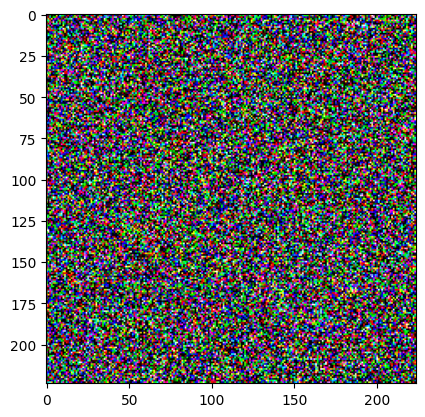

torch.Size([1, 4])


In [11]:
torch.manual_seed(112)
tImg = torch.randn((1, 3,224,224), dtype = torch.float32)
img = tImg[0].permute(1,2,0).numpy()
plt.imshow(img)
plt.show()
model = ViT()
res = model(tImg)
print(res.shape)

In [19]:
# Training settings
train_transforms = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
    ]
)

val_transforms = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
    ]
)

tensor(0)


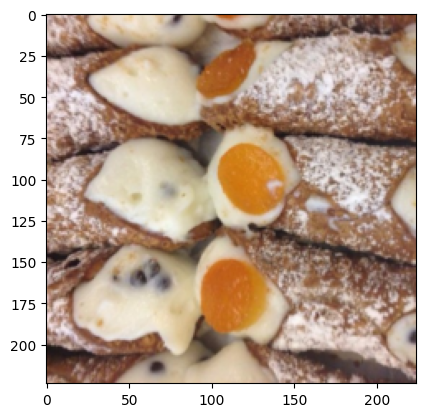

In [45]:
dataDir = 'drive/MyDrive/datasets/small_food'
# !ls drive/MyDrive/datasets/small_food
dataTransforms = transforms.Compose([
    transforms.Resize(size=(224,224)),
    transforms.ToTensor()
])
allData = datasets.ImageFolder(dataDir, transform=dataTransforms)
totalDataSize = len(allData)
trainSize = int(totalDataSize * 0.8)
valSize = totalDataSize - trainSize

torch.manual_seed(42)
trainData, valData = random_split(allData, [trainSize, valSize])
batchSize = 128
numWorker = 8
trainLoader = DataLoader(trainData, batchSize, shuffle = True, num_workers=numWorker, persistent_workers=True)
valLoader = DataLoader(valData, batchSize, shuffle = True, num_workers=numWorker, persistent_workers=True)

img, label = next(iter(trainLoader))

numData = 0
# dataMap = {'0':'cannoli', '1':'chicken_ques', '2':'fishnchips', '3':'friedRice'}
# print(f"{img[numData].shape}   {dataMap[str(label[numData].item())]}")


img = img[numData].numpy().swapaxes(0,2)
print(label[numData])
plt.imshow(img)
plt.show()

In [46]:
lr = 0.01
gamma = 0.7
device='cuda'
model = ViT(in_channels = 3,
                patch_size = 16,
                emb_size = 768,
                img_size  = 224,
                depth = 12,
                n_classes = 4).to(device)

model = torch.nn.DataParallel(model)
model = model.to(device)
model = torch.compile(model)
# loss function
criterion = nn.CrossEntropyLoss()
# optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
# scheduler
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=gamma)

In [47]:
from torch.profiler import profile, ProfilerActivity
epochs = 100


for epoch in range(epochs):
    epoch_loss = 0
    epoch_accuracy = 0
    model.train()
    for data, label in tqdm(trainLoader):
        data = data.to(device)
        label = label.to(device)

        output = model(data)
        loss = criterion(output, label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        acc = (output.argmax(dim=1) == label).float().mean()
        epoch_accuracy += acc / len(trainLoader)
        epoch_loss += loss / len(trainLoader)

    with torch.no_grad():
        epoch_val_accuracy = 0
        epoch_val_loss = 0
        model.eval()
        for data, label in valLoader:
            data = data.to(device)
            label = label.to(device)
            val_output = model(data)
            val_loss = criterion(val_output, label)

            acc = (val_output.argmax(dim=1) == label).float().mean()
            epoch_val_accuracy += acc / len(valLoader)
            epoch_val_loss += val_loss / len(valLoader)

    print(f"Epoch : {epoch+1} - loss : {epoch_loss:.4f} - acc: {epoch_accuracy:.4f} - val_loss : {epoch_val_loss:.4f} - val_acc: {epoch_val_accuracy:.4f}\n")


  0%|          | 0/25 [00:00<?, ?it/s]W0330 09:40:45.738000 556 torch/_logging/_internal.py:1204] [0/0] Profiler function <class 'torch.autograd.profiler.record_function'> will be ignored
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:321: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(
100%|██████████| 25/25 [00:40<00:00,  1.60s/it]


Epoch : 1 - loss : 3.6665 - acc: 0.2431 - val_loss : 1.5453 - val_acc: 0.2344



100%|██████████| 25/25 [00:21<00:00,  1.17it/s]


Epoch : 2 - loss : 1.5690 - acc: 0.2550 - val_loss : 1.5522 - val_acc: 0.2344



100%|██████████| 25/25 [00:21<00:00,  1.17it/s]


...

Epoch : 98 - loss : 1.3305 - acc: 0.3491 - val_loss : 1.3383 - val_acc: 0.3438



100%|██████████| 25/25 [00:21<00:00,  1.17it/s]


Epoch : 99 - loss : 1.3248 - acc: 0.3734 - val_loss : 1.3061 - val_acc: 0.3806



100%|██████████| 25/25 [00:21<00:00,  1.16it/s]


Epoch : 100 - loss : 1.3044 - acc: 0.3797 - val_loss : 1.3169 - val_acc: 0.3504

